# 3D TransUNet
This notebook implements a lightweight 3D TransUNet-style model for 3D MRI segmentation.

## Base References

1. **3D-TransUNet repository:**
   https://github.com/Beckschen/3D-TransUNet
2. **3D TransUNet paper:**
   https://arxiv.org/abs/2310.07781
3. **TransUNet repository:**
   https://github.com/Beckschen/TransUNet

The model below is intentionally sized for speed and memory safety.
- mixed precision
- image-chunk staging to GPU
- optional spatial-window training
- patch-chunked logits/loss computation
- frequent batch/epoch reporting

In [ ]:
import os
from pathlib import Path
import math
import random
import time

from nilearn.image import resample_to_img
from nilearn.datasets import load_mni152_template
import nibabel as nib

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# Repro + device
SEED = 1337
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

# Geometry
VOLUME_SHAPE = (208, 240, 192)
PATCH_SIZE = (16, 16, 16)

# Set to an int or None to infer from labels.
TARGET_N_CLASSES = None

# Model config
MODEL_CFG = {
    "in_channels": 1,
    "channels": (16, 24, 48, 72, 96, 128),
    "transformer_depth": 2,
    "n_heads": 4,
    "dropout": 0.1,
}

# Training config
TRAIN_CFG = {
    "epochs": 1000,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "image_bs": 1,
    "max_chunk_images": 8,
    "patch_chunk_size": 96,        # lower => safer VRAM, usually slower
    "spatial_window": None,        # None => full volume; or tuple like (104,120,96)
    "spatial_stride": None,        # None => same as window
    "auto_reduce_window_on_oom": True,
}


def gpu_mem_gb():
    if DEVICE != "cuda":
        return 0.0, 0.0
    return (
        torch.cuda.memory_allocated() / (1024**3),
        torch.cuda.max_memory_allocated() / (1024**3),
    )

In [ ]:
# Shape / data helpers

def patch_grid_from_shape(volume_shape=VOLUME_SHAPE, patch_size=PATCH_SIZE):
    if any(v % p != 0 for v, p in zip(volume_shape, patch_size)):
        raise ValueError(f"volume_shape={volume_shape} must be divisible by patch_size={patch_size}.")
    return tuple(v // p for v, p in zip(volume_shape, patch_size))


def ensure_divisible(shape, patch_size=PATCH_SIZE):
    if any(s % p != 0 for s, p in zip(shape, patch_size)):
        raise ValueError(f"shape={shape} must be divisible by patch_size={patch_size}.")


def patches_to_volume(patches, volume_shape=VOLUME_SHAPE, patch_size=PATCH_SIZE):
    """patches: [B, N, V] -> volume [B, D, H, W]"""
    if patches.ndim != 3:
        raise ValueError(f"Expected [B, N, V], got {tuple(patches.shape)}")
    b, n, v = patches.shape
    gd, gh, gw = patch_grid_from_shape(volume_shape, patch_size)
    pv = int(math.prod(patch_size))
    expected_n = gd * gh * gw
    if n != expected_n or v != pv:
        raise ValueError(f"Expected [B, {expected_n}, {pv}], got {tuple(patches.shape)}")
    pd, ph, pw = patch_size
    x = patches.reshape(b, gd, gh, gw, pd, ph, pw)
    x = x.permute(0, 1, 4, 2, 5, 3, 6).contiguous()
    return x.reshape(b, *volume_shape)


def volume_to_patches(volume, patch_size=PATCH_SIZE):
    """volume: [B, D, H, W] -> patches [B, N, V]"""
    if volume.ndim != 4:
        raise ValueError(f"Expected [B, D, H, W], got {tuple(volume.shape)}")
    b, d, h, w = volume.shape
    ensure_divisible((d, h, w), patch_size)
    pd, ph, pw = patch_size
    gd, gh, gw = d // pd, h // ph, w // pw
    x = volume.reshape(b, gd, pd, gh, ph, gw, pw)
    x = x.permute(0, 1, 3, 5, 2, 4, 6).contiguous()
    return x.reshape(b, gd * gh * gw, pd * ph * pw)


def to_feature_volume(x, ref_labels_volume=None, split_name="x"):
    """
    Normalize features to [B, D, H, W]. Supports:
      [B, D, H, W], [B, 1, D, H, W], [B, N, V], [B*N, V] (if ref given)
    """
    if x.ndim == 5:
        if x.shape[1] != 1:
            raise ValueError(f"{split_name}: expected C=1 for 5D input, got {tuple(x.shape)}")
        vol = x[:, 0]
    elif x.ndim == 4:
        vol = x
    elif x.ndim == 3:
        vol = patches_to_volume(x.float(), VOLUME_SHAPE, PATCH_SIZE)
    elif x.ndim == 2:
        if ref_labels_volume is None:
            raise ValueError(f"{split_name}: [B*N, V] requires ref_labels_volume to infer B.")
        b = ref_labels_volume.shape[0]
        n = int(math.prod(patch_grid_from_shape(VOLUME_SHAPE, PATCH_SIZE)))
        v = int(math.prod(PATCH_SIZE))
        expected = b * n
        if x.shape != (expected, v):
            raise ValueError(f"{split_name}: expected {(expected, v)} for reshape, got {tuple(x.shape)}")
        vol = patches_to_volume(x.reshape(b, n, v).float(), VOLUME_SHAPE, PATCH_SIZE)
    else:
        raise ValueError(f"{split_name}: unsupported ndim={x.ndim}")

    if tuple(vol.shape[1:]) != VOLUME_SHAPE:
        raise ValueError(f"{split_name}: expected spatial {VOLUME_SHAPE}, got {tuple(vol.shape[1:])}")
    return vol.float().contiguous()


def to_label_volume(y, split_name="y"):
    """
    Normalize labels to [B, D, H, W]. Supports:
      [B, D, H, W], [B, 1, D, H, W], [B, N, V]
    """
    if y.ndim == 5:
        if y.shape[1] != 1:
            raise ValueError(f"{split_name}: expected C=1 for 5D labels, got {tuple(y.shape)}")
        vol = y[:, 0]
    elif y.ndim == 4:
        vol = y
    elif y.ndim == 3:
        vol = patches_to_volume(y, VOLUME_SHAPE, PATCH_SIZE)
    else:
        raise ValueError(f"{split_name}: unsupported ndim={y.ndim}")

    if tuple(vol.shape[1:]) != VOLUME_SHAPE:
        raise ValueError(f"{split_name}: expected spatial {VOLUME_SHAPE}, got {tuple(vol.shape[1:])}")
    return vol.long().contiguous()


def remap_to_class_ids(y, class_values):
    idx = torch.searchsorted(class_values, y)
    idx_clamped = idx.clamp(max=class_values.numel() - 1)
    valid = (idx < class_values.numel()) & (class_values[idx_clamped] == y)
    if not bool(valid.all()):
        bad = torch.unique(y[~valid])[:10].tolist()
        raise ValueError(f"Found labels not present in class_values: {bad}")
    return idx.long()


def _positions_1d(dim, win, stride):
    if win > dim:
        raise ValueError(f"window {win} > dim {dim}")
    starts = list(range(0, dim - win + 1, stride))
    if starts[-1] != dim - win:
        starts.append(dim - win)
    return starts


def make_window_slices(spatial_shape, window_shape, stride_shape):
    d, h, w = spatial_shape
    wd, wh, ww = window_shape
    sd, sh, sw = stride_shape
    zs = _positions_1d(d, wd, sd)
    ys = _positions_1d(h, wh, sh)
    xs = _positions_1d(w, ww, sw)
    out = []
    for z0 in zs:
        for y0 in ys:
            for x0 in xs:
                out.append((slice(z0, z0 + wd), slice(y0, y0 + wh), slice(x0, x0 + ww)))
    return out


def reduce_window_shape(window_shape, patch_size=PATCH_SIZE):
    # Halve each axis, keep divisible by patch size, and not smaller than one patch.
    out = []
    for s, p in zip(window_shape, patch_size):
        half = max(p, s // 2)
        half = max(p, (half // p) * p)
        out.append(half)
    return tuple(out)

In [ ]:
def _group_norm(ch):
    for g in (8, 4, 2, 1):
        if ch % g == 0:
            return nn.GroupNorm(g, ch)
    return nn.GroupNorm(1, ch)


class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            _group_norm(out_ch),
            nn.GELU(),
            nn.Dropout3d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            _group_norm(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class DownBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.down = nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False)
        self.block = ConvBlock3D(out_ch, out_ch, dropout=dropout)

    def forward(self, x):
        return self.block(self.down(x))


class UpBlock3D(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.reduce = nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False)
        self.block = ConvBlock3D(out_ch + skip_ch, out_ch, dropout=dropout)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode="trilinear", align_corners=False)
        x = self.reduce(x)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


class TransUNet3D(nn.Module):
    """
    Encoder (3D CNN) -> Transformer bottleneck -> Decoder (3D CNN with skips)
    Output path is patch-chunked for VRAM-safe voxelwise CE loss.
    """

    def __init__(
        self,
        n_classes,
        in_channels=1,
        base_shape=VOLUME_SHAPE,
        patch_size=PATCH_SIZE,
        channels=(16, 24, 48, 72, 96, 128),
        transformer_depth=2,
        n_heads=4,
        dropout=0.1,
    ):
        super().__init__()
        if len(channels) != 6:
            raise ValueError("channels must have length 6.")

        self.n_classes = int(n_classes)
        self.base_shape = tuple(int(v) for v in base_shape)
        self.patch_size = tuple(int(v) for v in patch_size)
        self.patch_voxels = int(math.prod(self.patch_size))

        c0, c1, c2, c3, c4, c5 = [int(c) for c in channels]

        self.stem = ConvBlock3D(in_channels, c0, dropout=0.0)
        self.down1 = DownBlock3D(c0, c1, dropout=0.0)
        self.down2 = DownBlock3D(c1, c2, dropout=0.0)
        self.down3 = DownBlock3D(c2, c3, dropout=dropout)
        self.down4 = DownBlock3D(c3, c4, dropout=dropout)
        self.down5 = DownBlock3D(c4, c5, dropout=dropout)
        self.bottleneck_conv = ConvBlock3D(c5, c5, dropout=dropout)

        # Base positional embedding grid is computed from the declared base volume shape.
        g = list(self.base_shape)
        for _ in range(5):
            g = [(x + 1) // 2 for x in g]
        self.base_bottleneck_grid = tuple(g)
        self.pos_embed = nn.Parameter(torch.zeros(1, int(math.prod(g)), c5))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=c5,
            nhead=n_heads,
            dim_feedforward=4 * c5,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=transformer_depth)

        self.up5 = UpBlock3D(c5, c4, c4, dropout=dropout)
        self.up4 = UpBlock3D(c4, c3, c3, dropout=dropout)
        self.up3 = UpBlock3D(c3, c2, c2, dropout=dropout)
        self.up2 = UpBlock3D(c2, c1, c1, dropout=0.0)
        self.up1 = UpBlock3D(c1, c0, c0, dropout=0.0)

        self.token_norm = nn.LayerNorm(c0)
        self.classifier = nn.Linear(c0, self.n_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def _token_positional_embedding(self, btm):
        # btm: [B, C, D, H, W]
        seq_len = btm.shape[2] * btm.shape[3] * btm.shape[4]
        if seq_len == self.pos_embed.shape[1]:
            return self.pos_embed

        # Interpolate positional embedding in 3D if runtime token grid differs.
        pos3 = self.pos_embed.transpose(1, 2).reshape(1, btm.size(1), *self.base_bottleneck_grid)
        pos3 = F.interpolate(pos3, size=btm.shape[2:], mode="trilinear", align_corners=False)
        pos = pos3.flatten(2).transpose(1, 2)
        return pos

    def forward_features(self, x):
        # x: [B, 1, D, H, W]
        if x.ndim != 5 or x.shape[1] != 1:
            raise ValueError(f"Expected [B, 1, D, H, W], got {tuple(x.shape)}")

        x0 = self.stem(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)
        x3 = self.down3(x2)
        x4 = self.down4(x3)
        x5 = self.down5(x4)

        btm = self.bottleneck_conv(x5)
        seq = btm.flatten(2).transpose(1, 2)
        pos = self._token_positional_embedding(btm)
        seq = self.transformer(seq + pos)
        btm = seq.transpose(1, 2).reshape_as(btm)

        d4 = self.up5(btm, x4)
        d3 = self.up4(d4, x3)
        d2 = self.up3(d3, x2)
        d1 = self.up2(d2, x1)
        d0 = self.up1(d1, x0)
        return d0  # [B, C_out, D, H, W]

    def features_to_patch_features(self, feat):
        # feat: [B, C, D, H, W] -> [B, N, V, C]
        if feat.ndim != 5:
            raise ValueError(f"Expected [B, C, D, H, W], got {tuple(feat.shape)}")
        b, c, d, h, w = feat.shape
        ensure_divisible((d, h, w), self.patch_size)
        pd, ph, pw = self.patch_size
        gd, gh, gw = d // pd, h // ph, w // pw

        x = feat.reshape(b, c, gd, pd, gh, ph, gw, pw)
        x = x.permute(0, 2, 4, 6, 3, 5, 7, 1).contiguous()
        x = x.reshape(b, gd * gh * gw, pd * ph * pw, c)
        x = self.token_norm(x)
        return x

    def _iter_patch_logits(self, patch_feat, patch_chunk_size=96):
        # patch_feat: [B, N, V, C]
        n = patch_feat.shape[1]
        for s in range(0, n, patch_chunk_size):
            e = min(s + patch_chunk_size, n)
            chunk_feat = patch_feat[:, s:e]                 # [B, P, V, C]
            chunk_logits = self.classifier(chunk_feat)      # [B, P, V, K]
            yield s, e, chunk_logits

    def loss_from_features(self, feat, y_volume, patch_chunk_size=96):
        # y_volume: [B, D, H, W]
        y_patch = volume_to_patches(y_volume, self.patch_size).long()
        patch_feat = self.features_to_patch_features(feat)

        total_num = 0
        total_den = 0
        for s, e, logit in self._iter_patch_logits(patch_feat, patch_chunk_size=patch_chunk_size):
            tgt = y_patch[:, s:e]  # [B, P, V]
            ce = F.cross_entropy(logit.permute(0, 3, 1, 2), tgt)
            numel = int(tgt.numel())
            total_num += ce * numel
            total_den += numel
        return total_num / max(1, total_den)

    @torch.no_grad()
    def predict_volume(self, x, patch_chunk_size=96):
        # x: [B, 1, D, H, W]
        feat = self.forward_features(x)
        patch_feat = self.features_to_patch_features(feat)

        preds_patch = []
        for _, _, logit in self._iter_patch_logits(patch_feat, patch_chunk_size=patch_chunk_size):
            preds_patch.append(logit.argmax(dim=-1).cpu())  # [B, P, V]
        pred_patch = torch.cat(preds_patch, dim=1)
        pred_vol = patches_to_volume(pred_patch, volume_shape=tuple(x.shape[2:]), patch_size=self.patch_size)
        return pred_vol

def patchify(X, patch_size=(16, 16, 16)):
    """Convert the 3D image into patches.

    Parameters
    ----------
    X : numpy.ndarray
        The 3D image to be converted into patches.

    Returns
    -------
    numpy.ndarray
        The 4D array of patches.
    """
    assert all([i%2 == 0 for i in patch_size]), "Patch size must be base 2."
    return X.reshape((-1, *patch_size))

def pad_to_multiple(x, multiple=16, constant_values=0):
    pads = []
    for s in x.shape:
        new_s = ((s + multiple - 1) // multiple) * multiple
        total = new_s - s
        before = total // 2
        after = total - before
        pads.append((before, after))
    x_pad = np.pad(x, pads, mode="constant", constant_values=constant_values)
    return x_pad, pads


def unpad(x_pad, pads):
    slices = tuple(slice(p0, x_pad.shape[i] - p1) for i, (p0, p1) in enumerate(pads))
    return x_pad[slices]

In [ ]:
# load niftis
mni = load_mni152_template(1)

subdirs = os.listdir("hcp/")
subdirs.sort()

if not Path("X_train.pt").exists() or not Path("Y_train.pt").exists():
    if not Path("X.pt").exists():
        imgs = [
            resample_to_img(nib.load(f"hcp/{s}/T1w/T1w_acpc_dc_restore.nii.gz"), mni)
            for s in subdirs
        ]

        # pad to multiple of 16 for clean patching
        imgs = [pad_to_multiple(i.get_fdata(), multiple=16)[0] for i in imgs]

        X = torch.stack([torch.from_numpy(x).float() for x in imgs])
        torch.save(X, "X.pt")
    else:
        X = torch.load("X.pt")

    X = X - X.mean(dim=(1, 2, 3), keepdim=True)
    X = X / X.std(dim=(1, 2, 3), keepdim=True).clamp_min(1e-6)

    # split
    X_train = X[:-10]
    X_val = X[-10:]

    # patches, 16^3
    X_train = torch.stack([patchify(x, patch_size=(16, 16, 16)) for x in X_train])
    X_val = torch.stack([patchify(x, patch_size=(16, 16, 16)) for x in X_val])

    X_train = X_train.reshape(-1, 16, 16, 16)
    X_val = X_val.reshape(-1, 16, 16, 16)

    X_train = X_train.float()
    X_val = X_val.float()

    X_train = X_train.to("cuda")
    X_val = X_val.to("cuda")

    X_train = X_train.reshape(len(X_train), -1)
    X_val = X_val.reshape(len(X_val), -1)

    torch.save(X_train, "X_train.pt")
    torch.save(X_val, "X_val.pt")
else:
    X_train_raw = torch.load("X_train.pt", map_location="cpu")
    X_val_raw = torch.load("X_val.pt", map_location="cpu")

In [ ]:
if not Path("X_train_seg.pt").exists() or not Path("Y_train_seg.pt").exists():

    mni = load_mni152_template(1)

    subdirs = os.listdir("hcp/")
    subdirs.sort()

    segs = [
        resample_to_img(nib.load(f"hcp/{s}/T1w/aparc+aseg.nii.gz"), mni, interpolation="nearest")
        for s in subdirs
    ]
    segs = [pad_to_multiple(i.get_fdata(), multiple=16)[0] for i in segs]

    X_train_seg = torch.stack([torch.from_numpy(patchify(x, patch_size=(16, 16, 16)).reshape(2340, 4096)) for x in segs[:-10]])
    X_val_seg = torch.stack([torch.from_numpy(patchify(x, patch_size=(16, 16, 16)).reshape(2340, 4096)) for x in segs[-10:]])

    X_train = X_train.reshape(*X_train_seg.shape)
    X_val = X_val.reshape(*X_val_seg.shape)

    X_train_seg = X_train_seg.long()
    X_val_seg = X_val_seg.long()

    torch.save(X_train_seg, "X_train_seg.pt")
    torch.save(X_val_seg, "X_val_seg.pt")
else:
    Y_train_raw = torch.load("X_train_seg.pt", map_location="cpu")
    Y_val_raw = torch.load("X_val_seg.pt", map_location="cpu")

In [ ]:
# Prepare data
Ytr_vol_raw = to_label_volume(Y_train_raw, split_name="Y_train")
Yva_vol_raw = to_label_volume(Y_val_raw, split_name="Y_val")

Xtr_vol = to_feature_volume(X_train_raw, ref_labels_volume=Ytr_vol_raw, split_name="X_train")
Xva_vol = to_feature_volume(X_val_raw, ref_labels_volume=Yva_vol_raw, split_name="X_val")

# Remap arbitrary label IDs to contiguous [0..K-1] if needed.
label_values = torch.unique(torch.cat([Ytr_vol_raw.reshape(-1), Yva_vol_raw.reshape(-1)], dim=0)).sort().values
if TARGET_N_CLASSES is not None and int(label_values.numel()) != int(TARGET_N_CLASSES):
    raise ValueError(f"Expected {TARGET_N_CLASSES} classes, found {int(label_values.numel())}.")

if int(label_values.min()) == 0 and int(label_values.max()) == int(label_values.numel()) - 1:
    Ytr_vol = Ytr_vol_raw.long().contiguous()
    Yva_vol = Yva_vol_raw.long().contiguous()
else:
    Ytr_vol = remap_to_class_ids(Ytr_vol_raw, label_values)
    Yva_vol = remap_to_class_ids(Yva_vol_raw, label_values)

n_classes = int(label_values.numel())
print("X_train volume:", tuple(Xtr_vol.shape))
print("Y_train volume:", tuple(Ytr_vol.shape))
print("X_val volume:  ", tuple(Xva_vol.shape))
print("Y_val volume:  ", tuple(Yva_vol.shape))
print("n_classes:", n_classes)

X_train volume: (90, 208, 240, 192)
Y_train volume: (90, 208, 240, 192)
X_val volume:   (10, 208, 240, 192)
Y_val volume:   (10, 208, 240, 192)
n_classes: 114


In [ ]:
# Train

seg_model = TransUNet3D(
    n_classes=n_classes,
    in_channels=MODEL_CFG["in_channels"],
    base_shape=VOLUME_SHAPE,
    patch_size=PATCH_SIZE,
    channels=MODEL_CFG["channels"],
    transformer_depth=MODEL_CFG["transformer_depth"],
    n_heads=MODEL_CFG["n_heads"],
    dropout=MODEL_CFG["dropout"],
).to(DEVICE)

opt = torch.optim.AdamW(seg_model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=TRAIN_CFG["weight_decay"])
use_amp = DEVICE == "cuda"
amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_amp and amp_dtype == torch.float16)

epochs = int(TRAIN_CFG["epochs"])
image_bs = int(TRAIN_CFG["image_bs"])
patch_chunk_size = int(TRAIN_CFG["patch_chunk_size"])

window_shape = tuple(TRAIN_CFG["spatial_window"] or VOLUME_SHAPE)
stride_shape = tuple(TRAIN_CFG["spatial_stride"] or window_shape)
ensure_divisible(window_shape, PATCH_SIZE)
ensure_divisible(stride_shape, PATCH_SIZE)
window_slices = make_window_slices(VOLUME_SHAPE, window_shape, stride_shape)

# Chunk images staged to GPU (separate from mini-batch size).
max_chunk_images = int(TRAIN_CFG["max_chunk_images"])
if DEVICE == "cuda":
    total_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    staging_target_gb = min(3.0, max(0.8, 0.10 * total_vram_gb))
else:
    staging_target_gb = 0.5

bytes_per_image = (
    Xtr_vol[0].numel() * Xtr_vol.element_size()
    + Ytr_vol[0].numel() * Ytr_vol.element_size()
)
est_chunk_images = int((staging_target_gb * (1024**3)) // max(1, bytes_per_image))
chunk_images = max(image_bs, min(max_chunk_images, max(1, est_chunk_images)))

n_train = Xtr_vol.size(0)
n_val = Xva_vol.size(0)
if n_train != Ytr_vol.size(0) or n_val != Yva_vol.size(0):
    raise ValueError("Image counts between features and labels must match.")

num_train_batches = (n_train + image_bs - 1) // image_bs
num_val_batches = (n_val + image_bs - 1) // image_bs

def batch_loss_on_windows(x_batch, y_batch):
    # x_batch: [B, D, H, W], y_batch: [B, D, H, W]
    x_batch = x_batch.unsqueeze(1).float()  # [B, 1, D, H, W]
    total = 0.0
    for ws in window_slices:
        zs, ys, xs = ws
        xw = x_batch[:, :, zs, ys, xs]
        yw = y_batch[:, zs, ys, xs]
        with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
            feat = seg_model.forward_features(xw)
            loss_w = seg_model.loss_from_features(feat, yw, patch_chunk_size=patch_chunk_size)
        total = total + loss_w
    return total / max(1, len(window_slices))

for epoch in tqdm(range(1, epochs + 1), total=epochs):
    epoch_start = time.time()
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    # ---------- train ----------
    seg_model.train()
    perm = torch.randperm(n_train)
    train_num, train_den = 0.0, 0
    train_chunk_images = chunk_images

    train_pbar = tqdm(total=num_train_batches, desc=f"epoch {epoch:03d} train", leave=False)

    chunk_start = 0
    while chunk_start < n_train:
        current_chunk = min(train_chunk_images, n_train - chunk_start)
        chunk_idx = perm[chunk_start:chunk_start + current_chunk]
        try:
            x_chunk = Xtr_vol[chunk_idx].to(DEVICE, non_blocking=True)
            y_chunk = Ytr_vol[chunk_idx].to(DEVICE, non_blocking=True)
        except RuntimeError as e:
            if "out of memory" in str(e).lower() and current_chunk > image_bs:
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()
                train_chunk_images = max(image_bs, current_chunk // 2)
                print(f"[epoch {epoch:03d}] OOM staging chunk={current_chunk}; chunk_images -> {train_chunk_images}")
                continue
            raise

        b_start = 0
        while b_start < x_chunk.size(0):
            x_batch = x_chunk[b_start:b_start + image_bs]
            y_batch = y_chunk[b_start:b_start + image_bs]

            opt.zero_grad(set_to_none=True)
            try:
                loss = batch_loss_on_windows(x_batch, y_batch)
            except RuntimeError as e:
                if (
                    "out of memory" in str(e).lower()
                    and TRAIN_CFG["auto_reduce_window_on_oom"]
                    and tuple(window_shape) == tuple(VOLUME_SHAPE)
                ):
                    # First OOM fallback: reduce spatial window, then retry same batch.
                    if DEVICE == "cuda":
                        torch.cuda.empty_cache()
                    window_shape = reduce_window_shape(window_shape, PATCH_SIZE)
                    stride_shape = window_shape
                    window_slices = make_window_slices(VOLUME_SHAPE, window_shape, stride_shape)
                    print(f"[epoch {epoch:03d}] OOM in forward; window -> {window_shape}, windows={len(window_slices)}")
                    continue
                raise

            if scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                opt.step()

            train_num += loss.item() * y_batch.numel()
            train_den += y_batch.numel()

            train_pbar.update(1)
            alloc_gb, peak_gb = gpu_mem_gb()
            avg_batch_sec = (time.time() - epoch_start) / max(1, train_pbar.n)
            train_pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                avg=f"{(train_num/max(1,train_den)):.4f}",
                wins=len(window_slices),
                bt=f"{avg_batch_sec:.2f}s",
                vram=f"{alloc_gb:.1f}/{peak_gb:.1f}G",
            )

            b_start += image_bs

        chunk_start += current_chunk

    train_pbar.close()
    train_loss = train_num / max(1, train_den)

    # ---------- val ----------
    seg_model.eval()
    with torch.no_grad():
        val_num, val_den = 0.0, 0
        val_pbar = tqdm(total=num_val_batches, desc=f"epoch {epoch:03d} val", leave=False)

        for chunk_start in range(0, n_val, chunk_images):
            x_chunk = Xva_vol[chunk_start:chunk_start + chunk_images].to(DEVICE, non_blocking=True)
            y_chunk = Yva_vol[chunk_start:chunk_start + chunk_images].to(DEVICE, non_blocking=True)

            for b_start in range(0, x_chunk.size(0), image_bs):
                x_batch = x_chunk[b_start:b_start + image_bs]
                y_batch = y_chunk[b_start:b_start + image_bs]

                x_batch = x_batch.unsqueeze(1).float()
                total_loss = 0.0
                for ws in window_slices:
                    zs, ys, xs = ws
                    xw = x_batch[:, :, zs, ys, xs]
                    yw = y_batch[:, zs, ys, xs]
                    with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
                        feat = seg_model.forward_features(xw)
                        loss_w = seg_model.loss_from_features(feat, yw, patch_chunk_size=patch_chunk_size)
                    total_loss = total_loss + loss_w
                loss = total_loss / max(1, len(window_slices))

                val_num += loss.item() * y_batch.numel()
                val_den += y_batch.numel()

                val_pbar.update(1)
                alloc_gb, peak_gb = gpu_mem_gb()
                val_pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    wins=len(window_slices),
                    vram=f"{alloc_gb:.1f}/{peak_gb:.1f}G",
                )

        val_pbar.close()

    val_loss = val_num / max(1, val_den)
    alloc_gb, peak_gb = gpu_mem_gb()
    epoch_sec = time.time() - epoch_start
    print(
        f"epoch {epoch:03d} | train_ce: {train_loss:.4f} | val_ce: {val_loss:.4f} "
        f"| t: {epoch_sec:.1f}s | chunk_images: {train_chunk_images} "
        f"| window: {window_shape} ({len(window_slices)} windows) "
        f"| vram: {alloc_gb:.1f}/{peak_gb:.1f}GB"
    )

/tmp/ipykernel_34614/3728576604.py:102: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=transformer_depth)


  0%|          | 0/1000 [00:00<?, ?it/s]

epoch 001 train:   0%|          | 0/90 [00:00<?, ?it/s]

epoch 001 val:   0%|          | 0/10 [00:00<?, ?it/s]

epoch 001 | train_ce: 2.7086 | val_ce: 2.0607 | t: 47.7s | chunk_images: 8 | window: (208, 240, 192) (1 windows) | vram: 0.9/17.4GB


...

epoch 120 train:   0%|          | 0/90 [00:00<?, ?it/s]

epoch 120 val:   0%|          | 0/10 [00:00<?, ?it/s]

epoch 120 | train_ce: 0.0894 | val_ce: 0.0969 | t: 34.3s | chunk_images: 8 | window: (208, 240, 192) (1 windows) | vram: 0.9/18.2GB


epoch 121 train:   0%|          | 0/90 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Save checkpoint
torch.save(
    {
        "model_state": seg_model.state_dict(),
        "model_cfg": MODEL_CFG,
        "train_cfg": TRAIN_CFG,
        "volume_shape": VOLUME_SHAPE,
        "patch_size": PATCH_SIZE,
        "n_classes": n_classes,
    },
    "transunet3d_state.pt",
)

In [ ]:
# Predict on validation set (VRAM-safe, tiled)

# This uses non-overlapping tiles by default (stride == window) and writes directly into output volume.
seg_model.eval()

pred_vols = []
with torch.no_grad():
    pred_pbar = tqdm(total=Xva_vol.size(0), desc="val predict", leave=False)

    for i in range(Xva_vol.size(0)):
        x = Xva_vol[i:i+1].to(DEVICE, non_blocking=True).unsqueeze(1).float()  # [1,1,D,H,W]

        out = torch.empty((1, *VOLUME_SHAPE), dtype=torch.long)
        for zs, ys, xs in window_slices:
            xw = x[:, :, zs, ys, xs]
            pw = seg_model.predict_volume(xw, patch_chunk_size=TRAIN_CFG["patch_chunk_size"])  # [1,wd,wh,ww]
            out[:, zs, ys, xs] = pw

        pred_vols.append(out)
        pred_pbar.update(1)

    pred_pbar.close()

Yva_pred_vol = torch.cat(pred_vols, dim=0)                     # [B, D, H, W]
Yva_pred = volume_to_patches(Yva_pred_vol, patch_size=PATCH_SIZE)  # [B, 2340, 4096]
Yva_patch = volume_to_patches(Yva_vol, patch_size=PATCH_SIZE)

print("Yva_pred patch shape:", tuple(Yva_pred.shape))
print("Yva patch shape:     ", tuple(Yva_patch.shape))

val predict:   0%|          | 0/10 [00:00<?, ?it/s]

Yva_pred patch shape: (10, 2340, 4096)
Yva patch shape:      (10, 2340, 4096)


In [109]:
pred_vols = []
with torch.no_grad():
    pred_pbar = tqdm(total=Xva_vol.size(0), desc="val predict", leave=False)

    for i in range(Xva_vol.size(0)):
        x = Xva_vol[i:i+1].to(DEVICE, non_blocking=True).unsqueeze(1).float()  # [1,1,D,H,W]

        out = torch.empty((1, *VOLUME_SHAPE), dtype=torch.long)
        for zs, ys, xs in window_slices:
            xw = x[:, :, zs, ys, xs]
            pw = seg_model.predict_volume(xw, patch_chunk_size=TRAIN_CFG["patch_chunk_size"])  # [1,wd,wh,ww]
            out[:, zs, ys, xs] = pw

        pred_vols.append(out)
        pred_pbar.update(1)

    pred_pbar.close()

val predict:   0%|          | 0/10 [00:00<?, ?it/s]

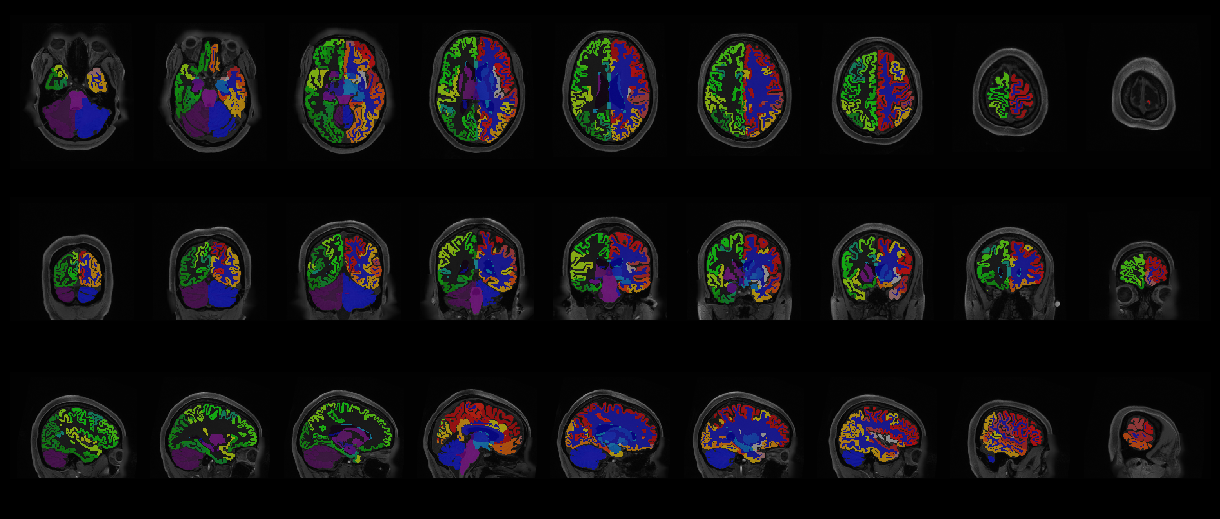

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import nibabel as nib
from nilearn.plotting import plot_roi
from nilearn.datasets import load_mni152_template

N_CLASSES = 114
i = -1

mni = load_mni152_template(resolution=1)
affine = mni.affine

# fixed class->color map
fixed_cmap = ListedColormap(plt.cm.nipy_spectral(np.linspace(0, 1, N_CLASSES)))
fixed_norm = BoundaryNorm(np.arange(-0.5, N_CLASSES + 0.5, 1), N_CLASSES, clip=True)

seg_vol  = Yva_patch[i].reshape(208, 240, 192).cpu().numpy().astype(np.int16)
pred_vol = Yva_pred[i].reshape(208, 240, 192).cpu().numpy().astype(np.int16)
anat_vol = X_val_raw.reshape(-1, 2340, 4096)[i].reshape(208, 240, 192).cpu().numpy().astype(np.float32)

anat_nii = nib.Nifti1Image(anat_vol, affine)

import nibabel as nib
from nilearn.plotting import plot_roi
from nilearn.plotting.find_cuts import find_cut_slices

# reference image to define slice locations (use one image only)
ref_nii = nib.Nifti1Image(seg_vol, affine)

fixed_cuts = {
    "x": find_cut_slices(ref_nii, direction="x", n_cuts=9),
    "y": find_cut_slices(ref_nii, direction="y", n_cuts=9),
    "z": find_cut_slices(ref_nii, direction="z", n_cuts=9),
}

def show_same_slices(vol, title):
    plot_roi(
        nib.Nifti1Image(vol, affine),
        bg_img=anat_nii,
        display_mode="mosaic",
        cut_coords=fixed_cuts,   # <- same exact cuts for all images
        cmap=fixed_cmap,
        alpha=0.6,
        colorbar=False,
        draw_cross=False,
        annotate=False,
        resampling_interpolation="nearest",
    )

show_same_slices(seg_vol, "GT")

plt.savefig("gt.svg", dpi=300)

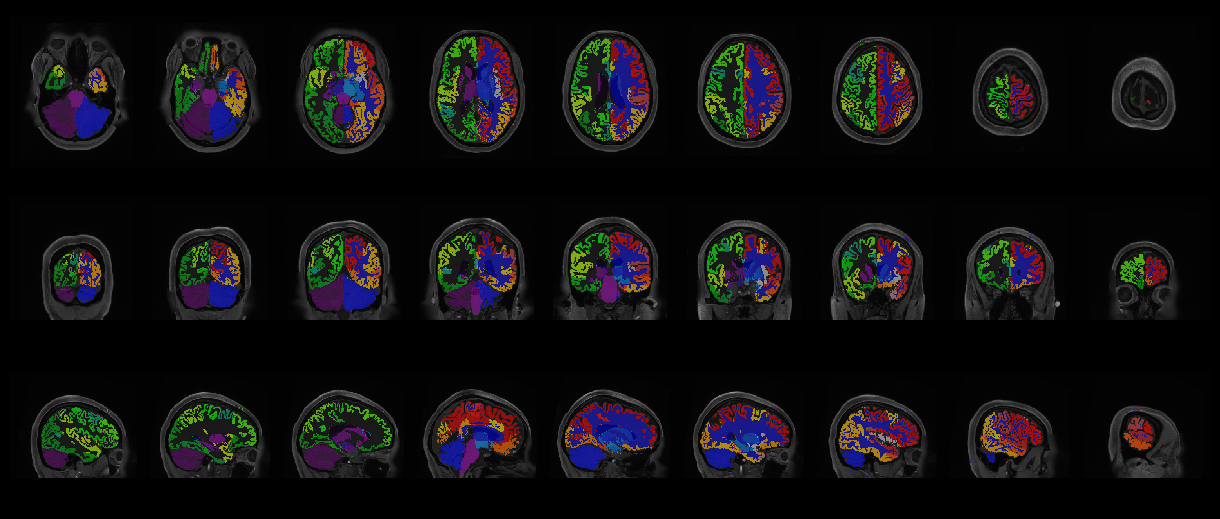

In [108]:
show_same_slices(pred_vol, "Pred")
plt.savefig("pred.svg", dpi=300)